In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("..\Datasets\loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
df.shape

(1000, 20)

In [4]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

## 1. Nulls handling

In [6]:
numeric_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

from sklearn.impute import SimpleImputer

# imputer for numeric cols 
num_imp = SimpleImputer(strategy='mean')
df[numeric_cols]= num_imp.fit_transform(df[numeric_cols])

# imputer for categorical cols
cat_imp = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

## 2. How balance our classes are 

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


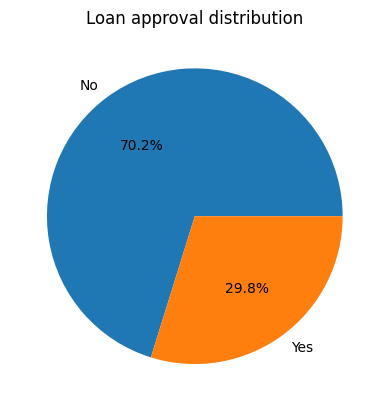

In [7]:
classes_count = df["Loan_Approved"].value_counts()
print(classes_count)

plt.pie(classes_count.values,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Loan approval distribution")
plt.show()

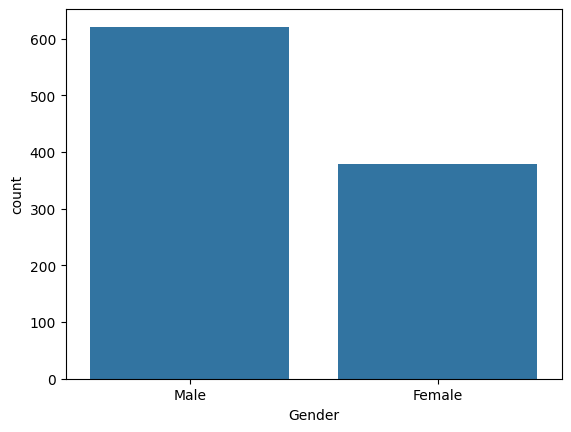

In [8]:
# analyze categories

gender_count = df["Gender"].value_counts()
sns.barplot(gender_count)
plt.show()

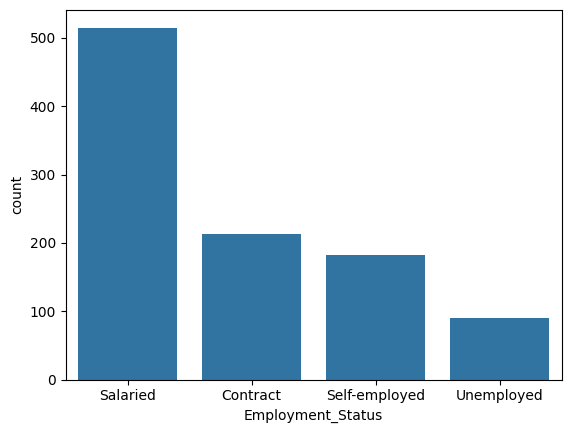

In [9]:
# analyze employment status by counts
employment_status = df["Employment_Status"].value_counts()
sns.barplot(employment_status)
plt.show()

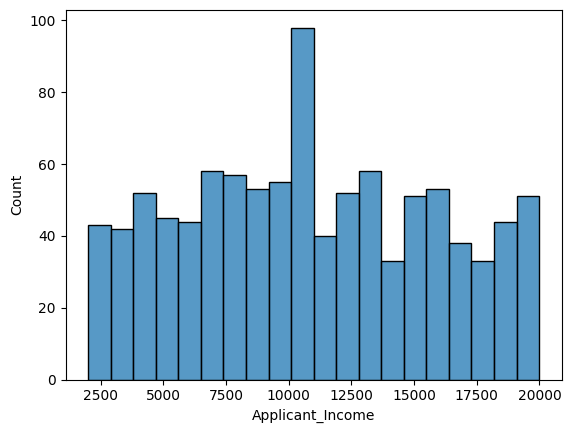

In [10]:
# analyze income 
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20
)
plt.show()

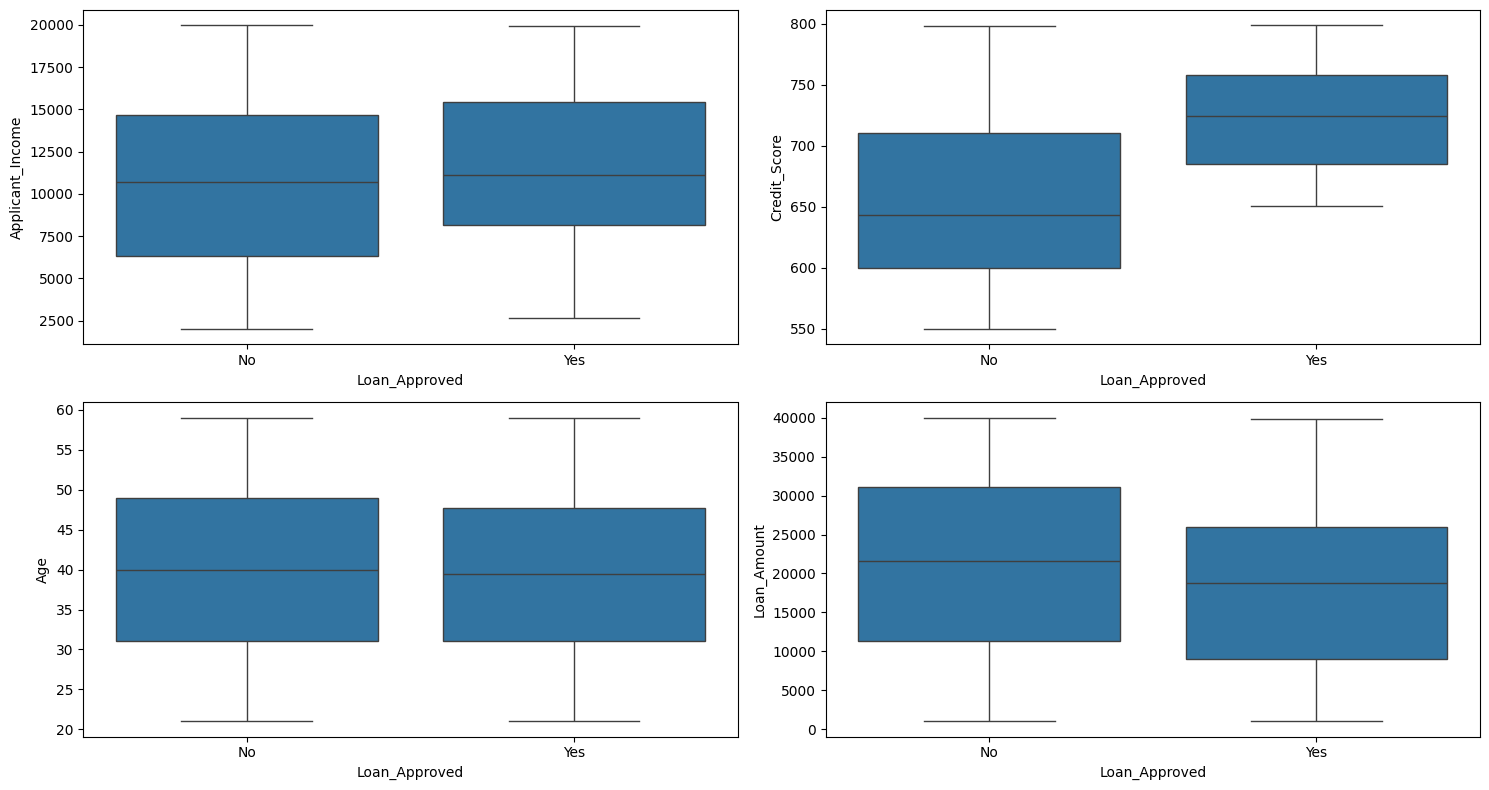

In [12]:
# Outliers - box plot

plt.figure(figsize=(15,8))
plt.subplot(2,2,1)  # Top Left
sns.boxplot(data = df,x="Loan_Approved",y = "Applicant_Income")

plt.subplot(2,2,2)  # Top Right
sns.boxplot(data = df,x="Loan_Approved",y = "Credit_Score")

plt.subplot(2,2,3)  # Bottom Left
sns.boxplot(data = df,x="Loan_Approved",y = "Age")

plt.subplot(2,2,4)  # Bottom Right
sns.boxplot(data = df,x="Loan_Approved",y = "Loan_Amount")

plt.tight_layout()
plt.show()

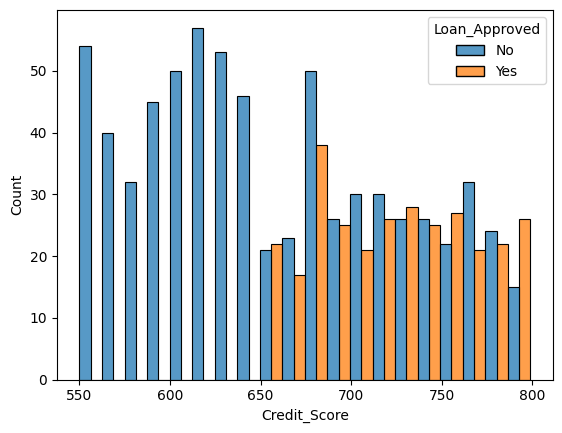

In [13]:
# Credit score and Approval

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)
plt.show()

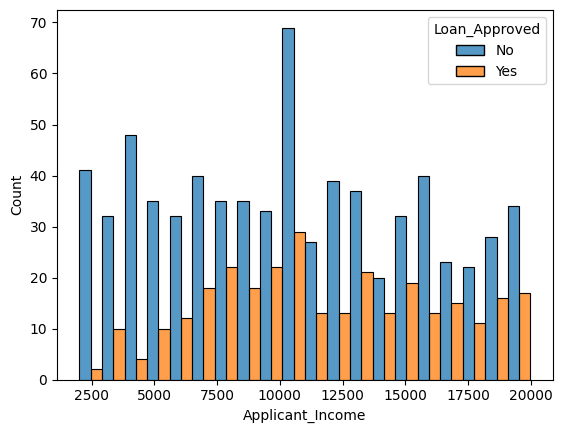

In [14]:

sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)
plt.show()

## 2.Encoding

In [15]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

# label encoder
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

# Ordinal encoder
oe = OrdinalEncoder(categories=[["Not Graduate","Graduate"]])
df["Education_Level"] = oe.fit_transform(df[["Education_Level"]])

# OneHot Encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Employer_Category"]
encoded = ohe.fit_transform(df[ohe_cols])


encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(),index=df.index)
df = pd.concat([df.drop(columns=ohe_cols),encoded_df],axis=1)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_ID                     1000 non-null   float64
 1   Applicant_Income                 1000 non-null   float64
 2   Coapplicant_Income               1000 non-null   float64
 3   Age                              1000 non-null   float64
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

### 3.Correlation

In [35]:
df.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employment_Status_Contract         0.082910
Employer_Category_MNC              0.069049
Education_Level                    0.052920
Loan_Purpose_Business              0.034767
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Business        -0.001472
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Property_Area_Rural               -0.017334
Employer_Category_Unemployed      -0.021468
Age                             

# Train test splitt + scling 

In [42]:
x = df.drop(columns="Loan_Approved")
y = df["Loan_Approved"]

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y , test_size= 0.2, random_state=42)
X_train.shape, X_test.shape

((800, 33), (200, 33))